In [29]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
with open('names.txt', 'r') as f:
    words = f.read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {c : i + 1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i : c for c, i in stoi.items()}
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
block_size = 3
X, Y = [], []

for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(f'{''.join(itos[i] for i in context)} --> {itos[ix]}')
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [64]:
X.shape, Y.shape, X.dtype, Y.dtype

(torch.Size([228146, 3]), torch.Size([228146]), torch.int64, torch.int64)

In [65]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(f'{''.join(itos[i] for i in context)} --> {itos[ix]}')
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1: n2])
Xtest, Ytest = build_dataset(words[n2:])


In [71]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)

W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [72]:
sum(p.nelement() for p in parameters)

11897

In [73]:
for p in parameters:
    p.requires_grad = True

In [74]:
stepi = []
lossi = []

In [79]:
epoch = 50000


for k in range(epoch):
    #minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
    
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])


    for p in parameters:
        p.grad = None
    
    loss.backward()

    lr = 0.01
    stepi.append(k)
    lossi.append(loss.log10().item())

    for p in parameters:
        p.data += -lr * p.grad
        
print(loss.item())

2.1693313121795654


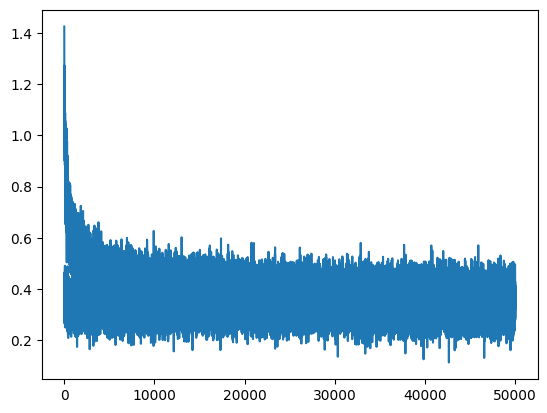

In [80]:
plt.plot(stepi, lossi)

In [81]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1703, grad_fn=<NllLossBackward0>)

In [82]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss

tensor(2.2154, grad_fn=<NllLossBackward0>)

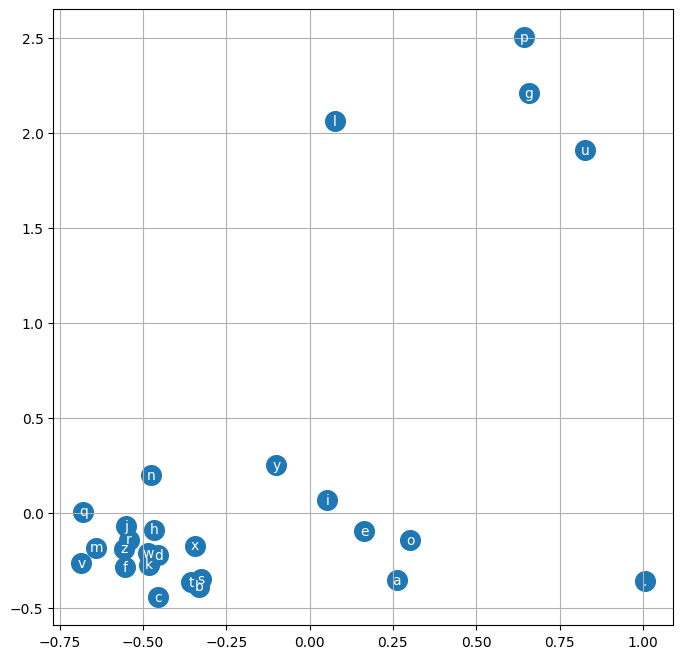

In [63]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [83]:
for _ in range(20):
    context = [0] * block_size
    out = []
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

bmainecharlin.
lia.
jammiel.
jozet.
harletiganiranle.
makyala.
xaviei.
merrady.
briam.
elorain.
anne.
tarlelssen.
smabrill.
evonne.
soriidah.
zyvan.
ella.
avaiylero.
dimir.
kenlinn.
